In [1]:
import random
import numpy as np
import os
import shutil
import time
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

# Set seeds for reproducibility
SEED = 0
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)

# Use GPU if available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


In [2]:
!pip install opendatasets
import opendatasets as od

od.download('https://www.kaggle.com/datasets/abdallahalidev/plantvillage-dataset')

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Dataset URL: https://www.kaggle.com/datasets/abdallahalidev/plantvillage-dataset


100%|██████████| 2.04G/2.04G [00:11<00:00, 192MB/s] 


In [3]:
# Explore dataset folders
print(os.listdir('/content/plantvillage-dataset'))
print(os.listdir('/content/plantvillage-dataset/plantvillage dataset'))

['plantvillage dataset']
['grayscale', 'segmented', 'color']


In [4]:
# Check number of classes in color folder
data_dir = '/content/plantvillage-dataset/plantvillage dataset/color'
print(f'Number of classes: {len(os.listdir(data_dir))}')
print(os.listdir(data_dir)[:5])

Number of classes: 38
['Cherry_(including_sour)___Powdery_mildew', 'Tomato___Tomato_mosaic_virus', 'Potato___Late_blight', 'Apple___Apple_scab', 'Tomato___healthy']


Prepare and Preprocess data

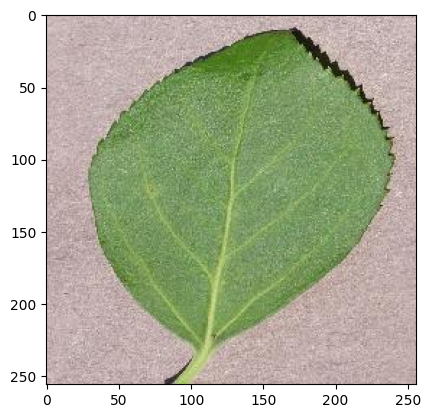

In [5]:
import matplotlib.image as mpimg
image_path = '/content/plantvillage-dataset/plantvillage dataset/color/Cherry_(including_sour)___healthy/01958ee7-f585-4956-90aa-a40dc79102d4___JR_HL 9836.JPG'

img = mpimg.imread(image_path)
plt.imshow(img)

In [6]:
IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 20
NUM_CLASSES = len(os.listdir(data_dir))  # 38


 Split Data into Train / Val / Test

In [ ]:
import shutil
import random

# Collect all file paths and labels
all_images = []
all_labels = []

for class_name in os.listdir(data_dir):
    class_path = os.path.join(data_dir, class_name)
    if os.path.isdir(class_path):
        for img_file in os.listdir(class_path):
            all_images.append(os.path.join(class_path, img_file))
            all_labels.append(class_name)

print(f'Total images: {len(all_images)}')

SUBSET_SIZE = 40000   

from collections import defaultdict
class_buckets = defaultdict(list)
for img, lbl in zip(all_images, all_labels):
    class_buckets[lbl].append(img)

imgs_per_class = SUBSET_SIZE // len(class_buckets)  

subset_images, subset_labels = [], []
for cls, imgs in class_buckets.items():
    sampled = random.sample(imgs, min(imgs_per_class, len(imgs)))
    subset_images.extend(sampled)
    subset_labels.extend([cls] * len(sampled))

print(f'Subset size: {len(subset_images)} images across {len(class_buckets)} classes')

# Now split the subset 80 / 10 / 10
train_imgs, temp_imgs, train_lbls, temp_lbls = train_test_split(
    subset_images, subset_labels, test_size=0.2, random_state=42, stratify=subset_labels
)
val_imgs, test_imgs, val_lbls, test_lbls = train_test_split(
    temp_imgs, temp_lbls, test_size=0.5, random_state=42, stratify=temp_lbls
)

print(f'Train : {len(train_imgs)} images')
print(f'Val   : {len(val_imgs)} images')
print(f'Test  : {len(test_imgs)} images')

# Copy files into split_data/ folder structure
def copy_images(img_paths, labels, split_name, base='split_data'):
    for img_path, label in zip(img_paths, labels):
        dest = os.path.join(base, split_name, label)
        os.makedirs(dest, exist_ok=True)
        shutil.copy(img_path, dest)

print('Copying files...')
copy_images(train_imgs, train_lbls, 'train')
copy_images(val_imgs,   val_lbls,   'val')
copy_images(test_imgs,  test_lbls,  'test')
print('Done! ✅')

Total images: 54305
Subset size: 33054 images across 38 classes
Train : 26443 images
Val   : 3305 images
Test  : 3306 images
Copying files...
Done! ✅


Create Data LOaders

In [ ]:
# Train transform: resize + augmentation + normalize
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),         
    transforms.RandomRotation(20),              
    transforms.RandomAffine(degrees=0, shear=0.2),  
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.8, 1.0)),  
    transforms.ToTensor(),                       
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# Val/Test transform: only resize + normalize (no augmentation)
test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE,IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# Load datasets using ImageFolder (reads class folders automatically)
train_dataset = datasets.ImageFolder('/content/split_data/train', transform=train_transform)
val_dataset   = datasets.ImageFolder('/content/split_data/val',   transform=test_transform)
test_dataset  = datasets.ImageFolder('/content/split_data/test',  transform=test_transform)

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

class_names = train_dataset.classes
NUM_CLASSES = len(class_names)

print(f'Train : {len(train_dataset)} images')
print(f'Val   : {len(val_dataset)} images')
print(f'Test  : {len(test_dataset)} images')
print(f'Classes: {NUM_CLASSES}')


Train : 26443 images
Val   : 3305 images
Test  : 3306 images
Classes: 38


 Visualize Sample Images

Image batch shape : torch.Size([32, 3, 224, 224])
Label batch shape : torch.Size([32])
Min pixel value   : -2.12
Max pixel value   : 2.64


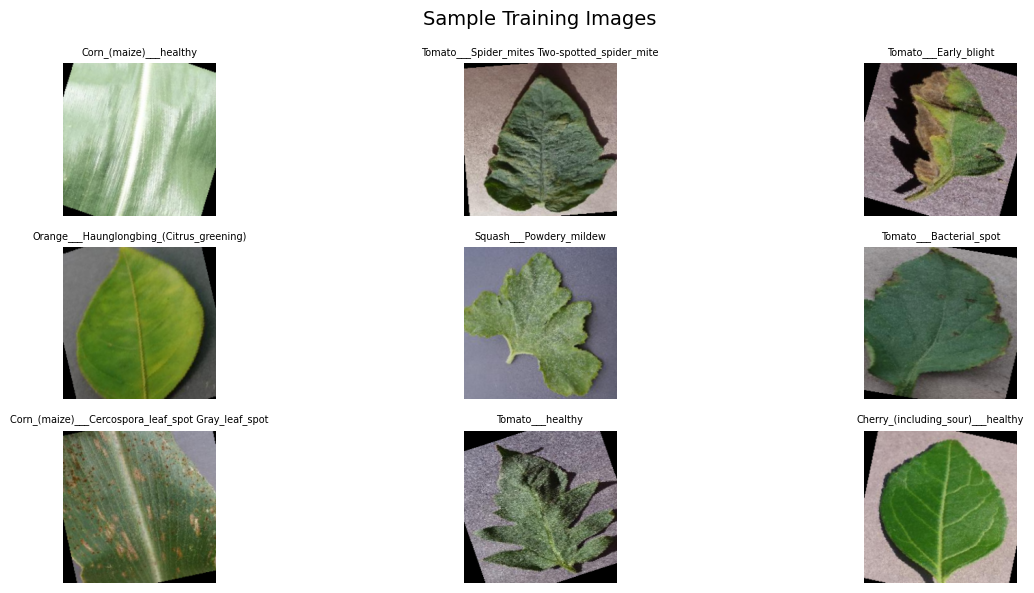

In [ ]:
# Get one batch
images, labels = next(iter(train_loader))

print(f'Image batch shape : {images.shape}')   # [32, 3, 128, 128]
print(f'Label batch shape : {labels.shape}')   # [32]
print(f'Min pixel value   : {images.min():.2f}')
print(f'Max pixel value   : {images.max():.2f}')

# Unnormalize for display
def unnormalize(img_tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
    return (img_tensor * std + mean).clamp(0, 1)

plt.figure(figsize=(14, 6))
for i in range(9):
    plt.subplot(3, 3, i+1)
    img = unnormalize(images[i]).permute(1, 2, 0).numpy()
    plt.imshow(img)
    plt.title(class_names[labels[i]], fontsize=7)
    plt.axis('off')
plt.suptitle('Sample Training Images', fontsize=14)
plt.tight_layout()
plt.show()

Training_code

In [ ]:
class PlantDiseaseCNN(nn.Module):
    def __init__(self, num_classes):
        super(PlantDiseaseCNN, self).__init__()

        def conv_block(in_ch, out_ch):
            return nn.Sequential(
                nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1),  # padding=1 preserves spatial size
                nn.BatchNorm2d(out_ch),
                nn.ReLU(),
                nn.MaxPool2d(2, 2)
            )

        self.block1 = conv_block(3,   32)
        self.block2 = conv_block(32,  64)
        self.block3 = conv_block(64,  128)
        self.block4 = conv_block(128, 256)

        self.pool = nn.AdaptiveAvgPool2d((1, 1))

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 512),
            nn.BatchNorm1d(512),      
            nn.ReLU(),
            nn.Dropout(0.5),          

            nn.Linear(512, num_classes)
        )

        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.block4(x)
        x = self.pool(x)          # → (batch, 256, 1, 1)
        x = self.classifier(x)   
        return x


model = PlantDiseaseCNN(NUM_CLASSES).to(device)
print(model)

PlantDiseaseCNN(
  (block1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block3): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block4): Sequential(
    (0): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (

In [11]:
print(model)

PlantDiseaseCNN(
  (block1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block3): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block4): Sequential(
    (0): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (

Training LOOP _1

In [12]:
import time

LEARNING_RATE = 0.001

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=3, factor=0.5)

best_val_acc = 0.0


In [ ]:
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=3, factor=0.5)

best_val_acc = 0.0

history = {
    'train_loss': [], 'train_acc': [],
    'val_loss':   [], 'val_acc':   []
}

start_time = time.time()

for epoch in range(EPOCHS):

    # TRAIN
    model.train()
    train_loss, train_correct = 0.0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * images.size(0)
        train_correct += (outputs.argmax(dim=1) == labels).sum().item()

    #  VALIDATE
    model.eval()
    val_loss, val_correct = 0.0, 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)
            val_correct += (outputs.argmax(dim=1) == labels).sum().item()

    #  AVERAGES
    train_loss_avg = train_loss / len(train_dataset)
    train_acc_avg  = train_correct / len(train_dataset)
    val_loss_avg   = val_loss / len(val_dataset)
    val_acc_avg    = val_correct / len(val_dataset)

    history['train_loss'].append(train_loss_avg)
    history['train_acc'].append(train_acc_avg)
    history['val_loss'].append(val_loss_avg)
    history['val_acc'].append(val_acc_avg)

    #  LR SCHEDULER (step on val loss)
    scheduler.step(val_loss_avg)

    #  SAVE BEST MODEL
    if val_acc_avg > best_val_acc:
        best_val_acc = val_acc_avg
        torch.save(model.state_dict(), 'best_model.pth')

    print(f'Epoch [{epoch+1:02d}/{EPOCHS}]  '
          f'Train Loss: {train_loss_avg:.4f}  Acc: {train_acc_avg:.4f}  '
          f'Val Loss: {val_loss_avg:.4f}  Acc: {val_acc_avg:.4f}  '
          f'LR: {optimizer.param_groups[0]["lr"]:.6f}')

end_time = time.time()
print(f'\nBest Val Acc: {best_val_acc:.4f}')
print(f'Total training time: {(end_time - start_time)/60:.2f} minutes')

Epoch [01/20]  Train Loss: 1.4286  Acc: 0.5765  Val Loss: 0.7816  Acc: 0.7440  LR: 0.001000
Epoch [02/20]  Train Loss: 0.6871  Acc: 0.7829  Val Loss: 0.4965  Acc: 0.8411  LR: 0.001000
Epoch [03/20]  Train Loss: 0.4774  Acc: 0.8478  Val Loss: 0.5139  Acc: 0.8384  LR: 0.001000
Epoch [04/20]  Train Loss: 0.3872  Acc: 0.8746  Val Loss: 0.2143  Acc: 0.9316  LR: 0.001000
Epoch [05/20]  Train Loss: 0.3232  Acc: 0.8963  Val Loss: 0.2626  Acc: 0.9123  LR: 0.001000
Epoch [06/20]  Train Loss: 0.2733  Acc: 0.9113  Val Loss: 0.2861  Acc: 0.9041  LR: 0.001000
Epoch [07/20]  Train Loss: 0.2443  Acc: 0.9195  Val Loss: 0.1985  Acc: 0.9337  LR: 0.001000
Epoch [08/20]  Train Loss: 0.2281  Acc: 0.9252  Val Loss: 0.3033  Acc: 0.9047  LR: 0.001000
Epoch [09/20]  Train Loss: 0.1941  Acc: 0.9350  Val Loss: 0.1880  Acc: 0.9322  LR: 0.001000
Epoch [10/20]  Train Loss: 0.1759  Acc: 0.9406  Val Loss: 0.2179  Acc: 0.9313  LR: 0.001000
Epoch [11/20]  Train Loss: 0.1691  Acc: 0.9444  Val Loss: 0.2246  Acc: 0.9244  L

plot Training History

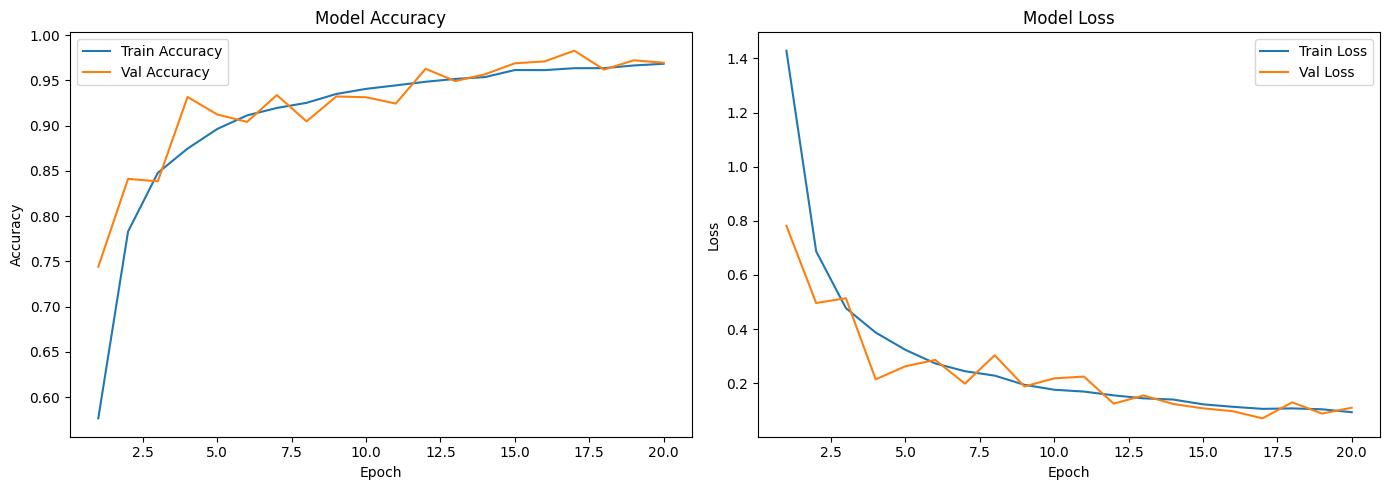

In [14]:
epochs_range = range(1,EPOCHS + 1)
plt.figure(figsize=(14, 5))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(epochs_range, history['train_acc'], label='Train Accuracy')
plt.plot(epochs_range, history['val_acc'],   label='Val Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(epochs_range, history['train_loss'], label='Train Loss')
plt.plot(epochs_range, history['val_loss'],   label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [15]:
model.eval()
test_correct = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        preds = outputs.argmax(dim=1)
        test_correct += (preds == labels).sum().item()

test_acc = test_correct / len(test_dataset)
print(f'Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)')

Test Accuracy: 0.9713 (97.13%)


In [ ]:

# Save model weights
torch.save(model.state_dict(), 'plant_disease_cnn.pth')
print('Model saved!')


Model saved!


In [ ]:
import shutil, json as _json

save_dir = '/content/drive/MyDrive/plant_disease_model'
os.makedirs(save_dir, exist_ok=True)

shutil.copy('best_model.pth', os.path.join(save_dir, 'best_model.pth'))
shutil.copy('plant_disease_cnn.pth', os.path.join(save_dir, 'plant_disease_cnn.pth'))


with open(os.path.join(save_dir, 'class_names.json'), 'w') as f:
    _json.dump(class_names, f)

print('Saved best_model.pth, plant_disease_cnn.pth and class_names.json to Drive ✅')

Saved best_model.pth, plant_disease_cnn.pth and class_names.json to Drive ✅


Using image: /content/split_data/test/Corn_(maize)___Common_rust_/RS_Rust 2127.JPG


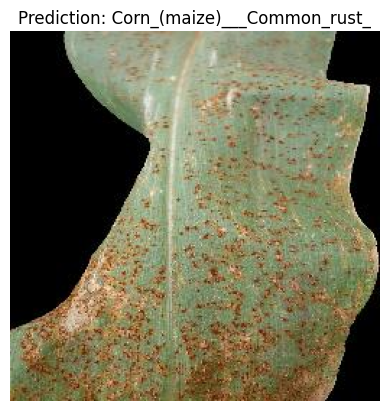

Predicted : Corn_(maize)___Common_rust_


In [ ]:
import os
from PIL import Image

def predict_image(image_path, model, class_names, device):
    # Load and preprocess
    img = Image.open(image_path).convert('RGB')
    transform = transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
    ])
    img_tensor = transform(img).unsqueeze(0).to(device)

    # Predict
    model.eval()
    with torch.no_grad():
        output = model(img_tensor)
        probabilities = torch.softmax(output, dim=1)
        predicted_idx = probabilities.argmax(dim=1).item()
        confidence = probabilities[0][predicted_idx].item()

    plt.imshow(img)
    plt.title(f'Prediction: {class_names[predicted_idx]}')
    plt.axis('off')
    plt.show()

    return class_names[predicted_idx], confidence

folder = '/content/split_data/test/Corn_(maize)___Common_rust_'
first_image = os.path.join(folder, os.listdir(folder)[0])
print("Using image:", first_image)

# ── Predict
predicted_class, confidence = predict_image(
    image_path=first_image,
    model=model,
    class_names=class_names,
    device=device
)

print(f"Predicted : {predicted_class}")
